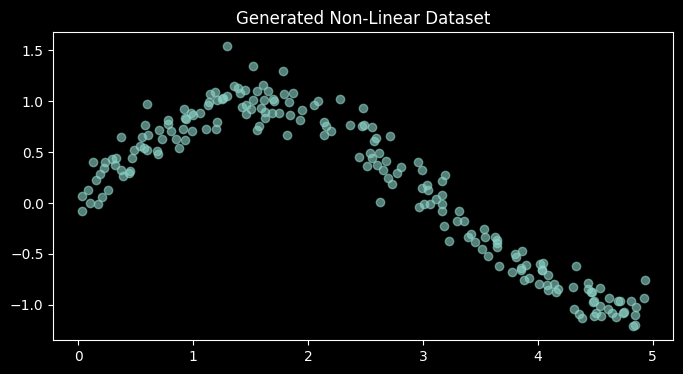

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from trees.regression.base_regression_tree import RegressionTree

# 1. Generate non-linear data (a noisy sine wave)
np.random.seed(42)
X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.15, X.shape[0])

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.6)
plt.title("Generated Non-Linear Dataset")
plt.show()

In [2]:
# Hyperparameters for an apples-to-apples comparison
max_depth = 5
min_samples_split = 2
min_samples_leaf = 5

# Instantiate and fit your custom tree
custom_tree = RegressionTree(
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf
)
custom_tree.fit(X_train, y_train)
print("Custom tree fitted successfully!")

# Instantiate and fit scikit-learn's tree
sklearn_tree = DecisionTreeRegressor(
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf
)
sklearn_tree.fit(X_train, y_train)
print("Scikit-learn tree fitted successfully!")

Custom tree fitted successfully!
Scikit-learn tree fitted successfully!


In [3]:
# Generate predictions on the unseen test set
y_pred_custom = custom_tree.predict(X_test)
y_pred_sklearn = sklearn_tree.predict(X_test)

# Calculate Mean Squared Error
mse_custom = mean_squared_error(y_test, y_pred_custom)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)

print(f"Custom Tree Test MSE:  {mse_custom:.5f}")
print(f"Sklearn Tree Test MSE: {mse_sklearn:.5f}")
print("-" * 30)
if abs(mse_custom - mse_sklearn) < 0.01:
    print("Success: Your tree is performing identically to sklearn!")
else:
    print("Note: Minor differences can occur due to how sklearn handles random ties.")

Custom Tree Test MSE:  0.03588
Sklearn Tree Test MSE: 0.03588
------------------------------
Success: Your tree is performing identically to sklearn!


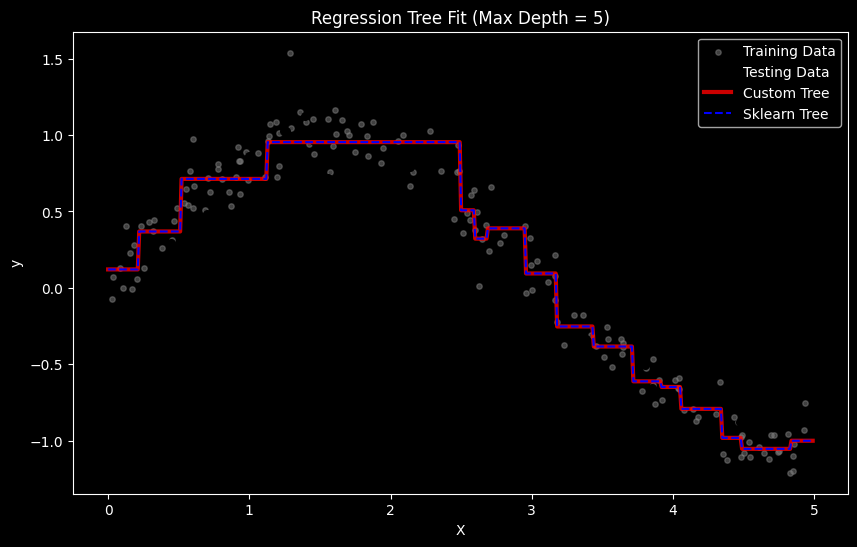

In [4]:
# Generate a dense grid of X values to plot the step-function line smoothly
X_grid = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_grid_custom = custom_tree.predict(X_grid)
y_grid_sklearn = sklearn_tree.predict(X_grid)

plt.figure(figsize=(10, 6))

# Plot the data points
plt.scatter(X_train, y_train, s=15, color="gray", label="Training Data", alpha=0.5)
plt.scatter(X_test, y_test, s=30, color="black", label="Testing Data")

# Plot the tree boundaries
plt.plot(X_grid, y_grid_custom, color="red", linewidth=3, label="Custom Tree", alpha=0.8)
plt.plot(X_grid, y_grid_sklearn, color="blue", linewidth=1.5, linestyle="--", label="Sklearn Tree")

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Regression Tree Fit (Max Depth = {max_depth})")
plt.legend()
plt.show()

In [5]:
custom_tree.print_tree()

Regression Tree Structure:
[Feature_0 < 3.1749]
├── [Feature_0 < 2.5971]
│   ├── [Feature_0 < 0.5139]
│   │   ├── [Feature_0 < 0.2181]
│   │   │   ├── Leaf: value = 0.1203
│   │   │   └── Leaf: value = 0.3686
│   │   └── [Feature_0 < 2.4998]
│   │       ├── [Feature_0 < 1.1215]
│   │       │   ├── Leaf: value = 0.7127
│   │       │   └── Leaf: value = 0.9534
│   │       └── Leaf: value = 0.5074
│   └── [Feature_0 < 2.9583]
│       ├── [Feature_0 < 2.6878]
│       │   ├── Leaf: value = 0.3216
│       │   └── Leaf: value = 0.3891
│       └── Leaf: value = 0.0937
└── [Feature_0 < 4.0596]
    ├── [Feature_0 < 3.7129]
    │   ├── [Feature_0 < 3.4379]
    │   │   ├── Leaf: value = -0.2532
    │   │   └── Leaf: value = -0.3844
    │   └── [Feature_0 < 3.9126]
    │       ├── Leaf: value = -0.6123
    │       └── Leaf: value = -0.6491
    └── [Feature_0 < 4.3441]
        ├── Leaf: value = -0.7926
        └── [Feature_0 < 4.4830]
            ├── Leaf: value = -0.9824
            └── [Feature_0 